# Demand Forecasting

Compare seasonal naive, Holt-Winters, XGBoost, and LSTM for household electricity demand forecasting.

XGBoost is evaluated in two scenarios: **nowcast** (may use the actual reading from 1 hour ago — realistic for a live smart-meter feed) and **day-ahead** (no data more recent than 24h before the target — the realistic input available when scheduling battery charge/discharge a full day in advance, which is what the next stage of this project needs).

2026-07-28 09:16:49,578 INFO Train: 26373 rows, Test: 7627 rows


/Users/despeinaw/Downloads/energy-ai-optimization/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/Users/despeinaw/Downloads/energy-ai-optimization/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/despeinaw/Downloads/energy-ai-optimization/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


2026-07-28 09:16:54,634 INFO Top 10 XGBoost (day-ahead) feature importances:
global_active_power_kw_lag_168h         0.255707
hour                                    0.135501
global_active_power_kw_lag_24h          0.101011
day_of_week                             0.062411
shortwave_radiation                     0.055764
global_active_power_kw_lag_48h          0.052937
is_holiday                              0.048675
global_active_power_kw_rollmean_24h     0.047418
global_active_power_kw_rollmean_168h    0.046777
month                                   0.040239
dtype: float32


2026-07-28 09:16:55,325 INFO Saved SHAP summary plot to /Users/despeinaw/Downloads/energy-ai-optimization/reports/figures/shap_summary.png


2026-07-28 09:17:07,965 INFO Model comparison:
                                       RMSE       MAE        MAPE
XGBoost (nowcast, uses last hour)  0.492859  0.342959   42.748633
XGBoost (day-ahead)                0.619184  0.450147   62.233110
LSTM                               0.651982  0.478176   65.745022
Seasonal Naive (day-ahead)         0.824785  0.560239   68.690212
Holt-Winters                       1.147806  0.978582  187.182486


2026-07-28 09:17:08,077 INFO Saved comparison plot to /Users/despeinaw/Downloads/energy-ai-optimization/reports/figures/forecast_comparison.png


,RMSE,MAE,MAPE
"XGBoost (nowcast, uses last hour)",0.492859,0.342959,42.748633
XGBoost (day-ahead),0.619184,0.450147,62.233110
LSTM,0.651982,0.478176,65.745022
Seasonal Naive (day-ahead),0.824785,0.560239,68.690212
Holt-Winters,1.147806,0.978582,187.182486


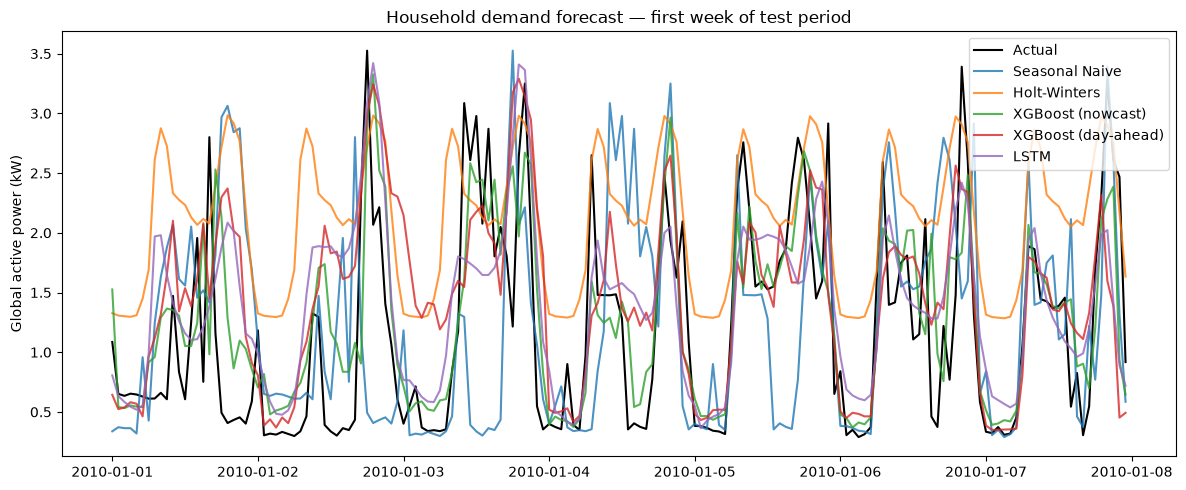

In [1]:
import sys
sys.path.insert(0, '..')
from src.run_forecasting import main

comparison = main()
comparison

## Forecast comparison — first week of the test period

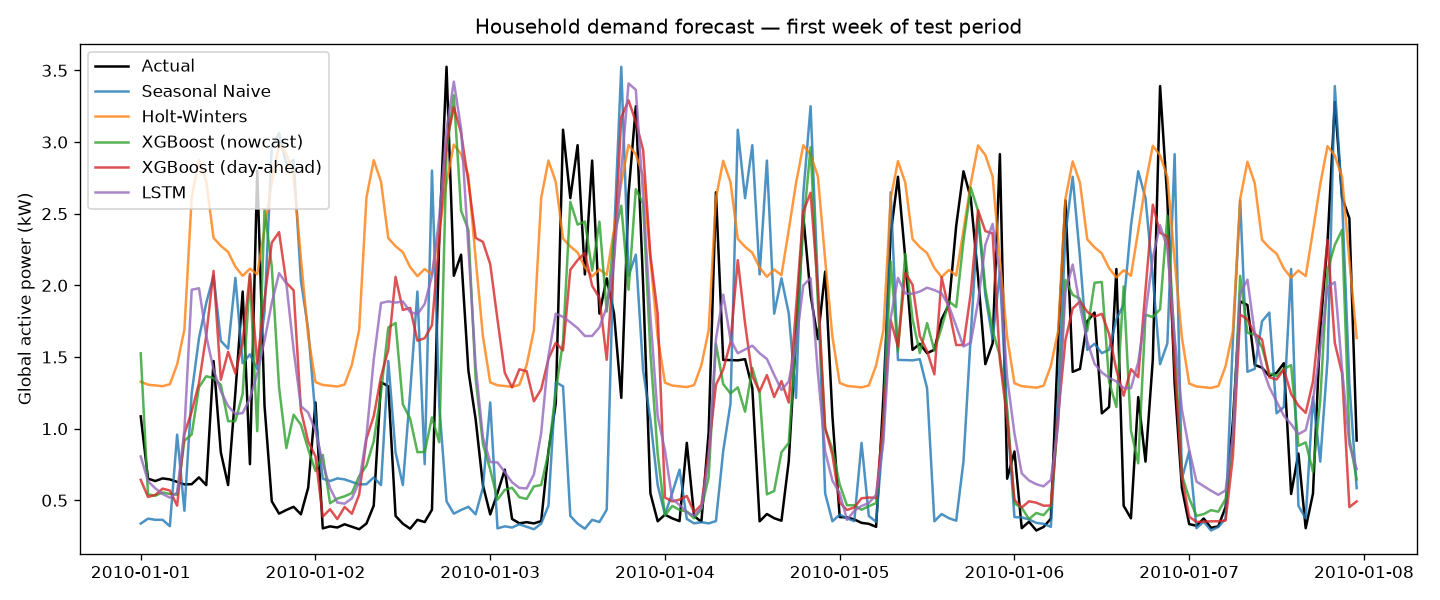

In [2]:
from IPython.display import Image
Image('../reports/figures/forecast_comparison.png')

## Which features drive the day-ahead forecast (SHAP)

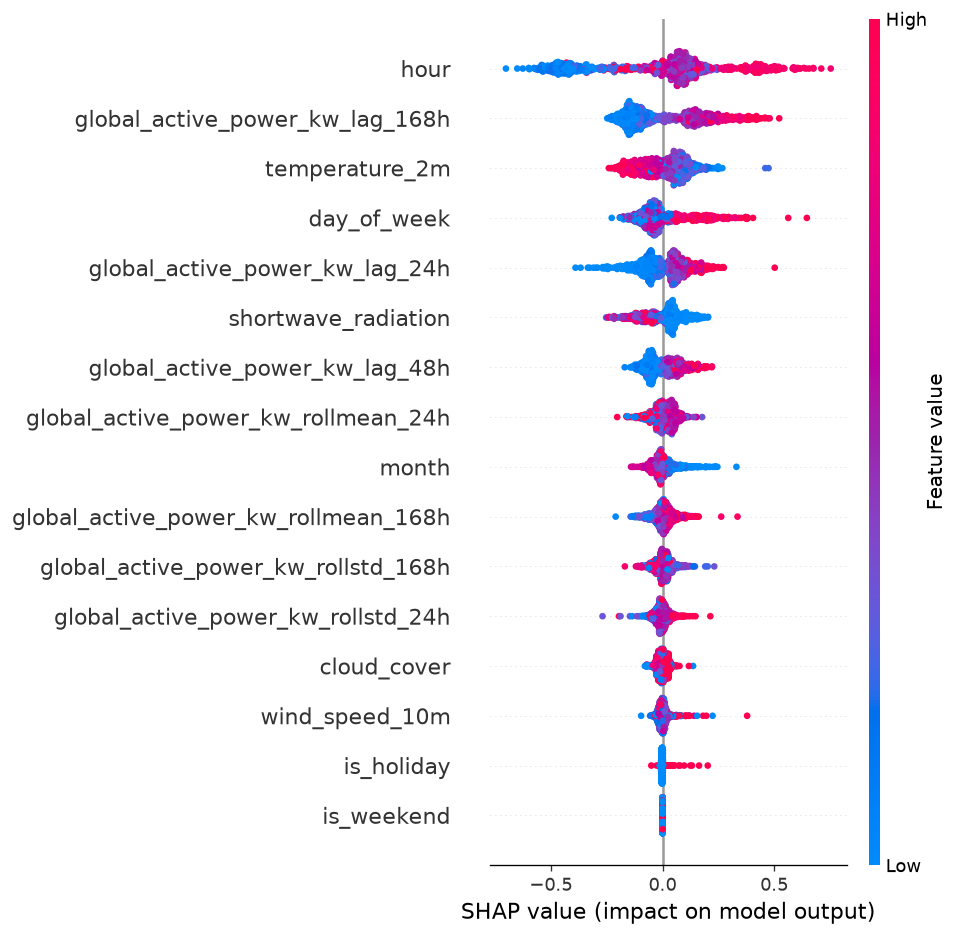

In [3]:
from IPython.display import Image
Image('../reports/figures/shap_summary.png')

## Discussion

- **XGBoost (day-ahead)** is the most accurate model that is actually usable for planning a full day of battery charge/discharge ahead of time, and is what feeds the battery optimization stage.
- **XGBoost (nowcast)** scores lower error, but only because it has access to the true reading from 1 hour before the target — useful for live monitoring, not for day-ahead planning.
- **LSTM** uses only weather and calendar features (no lagged demand) and still beats both baselines, showing it learns the daily/weekly demand pattern from context alone.
- **Seasonal naive** (same hour, previous day) and **Holt-Winters** are included as classical reference baselines; both are consistently outperformed by the learned models.